In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
df= pd.read_csv('marks_dataset.csv')
display(df.head())

,student_name,maths_marks,science_marks,english_marks,social_studies_marks,language_marks
0,Mr. Gregory Homenick,69,24,52,4,83
1,Marlene Leffler IV,62,59,70,54,52
2,Josephine Ebert,29,76,13,8,19
3,Dr. Irene Green,44,66,14,2,14
4,Jake Huel,49,23,63,86,68


<Axes: xlabel='maths_marks', ylabel='Density'>

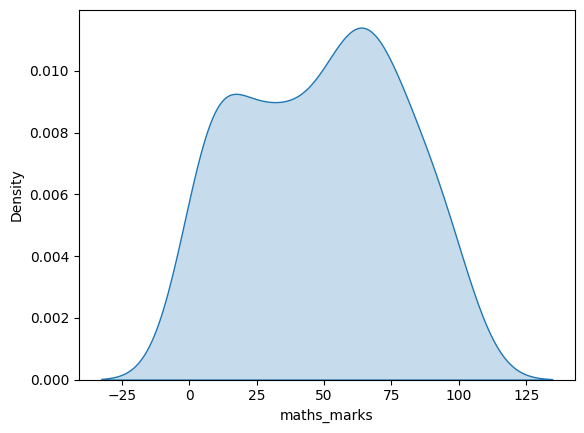

In [9]:
sns.kdeplot(data=df, x='maths_marks', fill=True)

Not normally distibuted data so cant use Z_score 


<Axes: xlabel='maths_marks'>

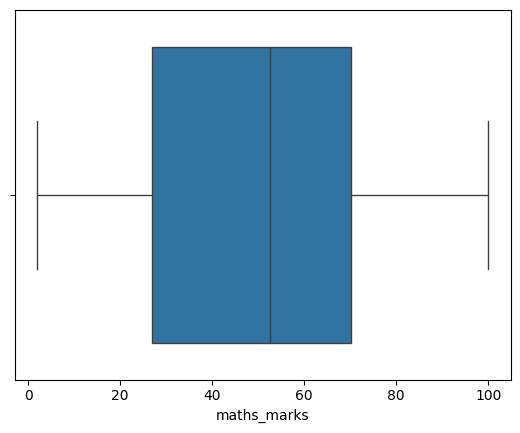

In [10]:
sns.boxplot(data=df , x= df['maths_marks'])

boxplot does not show  any outliners so cant use IQR 

In [11]:
df['maths_marks'].describe()

count    100.000000
mean      48.950000
std       28.999956
min        2.000000
25%       27.000000
50%       52.500000
75%       70.250000
max      100.000000
Name: maths_marks, dtype: float64

### Lets use WInsorization to handle outliners  ###

trial and error method to find the value of x

In [ ]:

x=14/100 
# 14% data is on the left and 14% data is on the right 
# so we are left with 72% data in the middle 

min_value = df['maths_marks'].quantile(x)  
max_value = df['maths_marks'].quantile(1-x) 
print(min_value)
print(max_value)


10.0
81.28


clipping menas if any value is less than min_value then replace it with min_value and if any value is greater than max_value then replace it with max_value

In [17]:
df['maths_marks'].clip(lower=min_value, upper=max_value, inplace=True)
df['maths_marks'].describe()

count    100.000000
mean      47.879200
std       25.977916
min       10.000000
25%       27.000000
50%       52.500000
75%       70.250000
max       81.280000
Name: maths_marks, dtype: float64